In [1]:
import os

COMBINED_TB     = "/kaggle/input/notebooks/maramalhinai/tb-classfication/combined_dataset/TB"
COMBINED_NORMAL = "/kaggle/input/notebooks/maramalhinai/tb-classfication/combined_dataset/Normal"

tb_count     = len(os.listdir(COMBINED_TB))
normal_count = len(os.listdir(COMBINED_NORMAL))

print(f"TB images     : {tb_count}")
print(f"Normal images : {normal_count}")
print(f"Total         : {tb_count + normal_count}")
print(f"\nSample TB     : {os.listdir(COMBINED_TB)[:3]}")
print(f"Sample Normal : {os.listdir(COMBINED_NORMAL)[:3]}")

TB images     : 995
Normal images : 3826
Total         : 4821

Sample TB     : ['shenzhen_CHNCXR_0660_1.png', '6CTuberculosis-629.png', 'shenzhen_CHNCXR_0578_1.png']
Sample Normal : ['original_Normal-1527.png', 'original_Normal-2305.png', 'original_Normal-3427.png']


In [2]:
import os, gc, random, shutil
import numpy as np
import cv2
import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras.applications import ResNet50, EfficientNetB0, DenseNet121
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix, roc_curve
from sklearn.utils.class_weight import compute_class_weight
from statsmodels.stats.contingency_tables import mcnemar
import shap
import matplotlib.pyplot as plt
import pandas as pd
import warnings
warnings.filterwarnings("ignore")

# ── Seeds ──
SEED = 42
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)

# ── Config ──
IMG_SIZE   = 224
BATCH_SIZE = 32
WORK_DIR   = "/kaggle/working/data_split"

# ── Source paths — using the pre-merged combined_dataset ──
COMBINED_TB     = "/kaggle/input/notebooks/maramalhinai/tb-classfication/combined_dataset/TB"
COMBINED_NORMAL = "/kaggle/input/notebooks/maramalhinai/tb-classfication/combined_dataset/Normal"

print("Config ready.")
print(f"TB: {len(os.listdir(COMBINED_TB))} | Normal: {len(os.listdir(COMBINED_NORMAL))}")

2026-04-28 16:32:36.665021: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777393956.847148      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777393956.903314      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1777393957.343936      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777393957.343975      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777393957.343978      55 computation_placer.cc:177] computation placer alr

Config ready.
TB: 995 | Normal: 3826


In [3]:
def get_paths_labels(tb_dir, normal_dir):
    paths, labels = [], []
    for f in os.listdir(tb_dir):
        if f.lower().endswith((".png",".jpg",".jpeg")):
            paths.append(os.path.join(tb_dir, f))
            labels.append(1)
    for f in os.listdir(normal_dir):
        if f.lower().endswith((".png",".jpg",".jpeg")):
            paths.append(os.path.join(normal_dir, f))
            labels.append(0)
    return np.array(paths), np.array(labels)


def build_split_folders(force=False):
    if os.path.exists(WORK_DIR) and not force:
        print("Split folders already exist. Pass force=True to rebuild.")
        _print_split_counts()
        return

    paths, labels = get_paths_labels(COMBINED_TB, COMBINED_NORMAL)
    print(f"Total images: {len(paths)} | TB={labels.sum()} | Normal={(labels==0).sum()}")

    idx = np.arange(len(paths))

    # 70 / 15 / 15 stratified split
    tr_idx, tmp_idx = train_test_split(idx, test_size=0.30,
                                       stratify=labels, random_state=SEED)
    vl_idx, ts_idx  = train_test_split(tmp_idx, test_size=0.50,
                                       stratify=labels[tmp_idx], random_state=SEED)

    label_map = {0: "Normal", 1: "TB"}
    split_map = {"train": tr_idx, "val": vl_idx, "test": ts_idx}

    for split, idxs in split_map.items():
        for lbl_str in label_map.values():
            os.makedirs(os.path.join(WORK_DIR, split, lbl_str), exist_ok=True)
        for i in idxs:
            src      = paths[i]
            lbl_str  = label_map[labels[i]]
            dst      = os.path.join(WORK_DIR, split, lbl_str, os.path.basename(src))
            shutil.copy2(src, dst)

    _print_split_counts()


def _print_split_counts():
    for split in ["train", "val", "test"]:
        for cls in ["TB", "Normal"]:
            folder = os.path.join(WORK_DIR, split, cls)
            n = len(os.listdir(folder)) if os.path.exists(folder) else 0
            print(f"  {split:5s}/{cls:6s}: {n}")


build_split_folders()

Total images: 4821 | TB=995 | Normal=3826
  train/TB    : 696
  train/Normal: 2678
  val  /TB    : 149
  val  /Normal: 574
  test /TB    : 150
  test /Normal: 574


In [4]:
def clahe_preprocess(img):
    img_u8 = np.clip(img, 0, 255).astype(np.uint8)
    clahe  = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    out    = np.zeros_like(img_u8)
    for c in range(3):
        out[:,:,c] = clahe.apply(img_u8[:,:,c])
    return out.astype(np.float32) / 255.0


def effnet_preprocess(img):
    from tensorflow.keras.applications.efficientnet import preprocess_input
    img_u8 = np.clip(img, 0, 255).astype(np.uint8)
    clahe  = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    out    = np.zeros_like(img_u8)
    for c in range(3):
        out[:,:,c] = clahe.apply(img_u8[:,:,c])
    return preprocess_input(out.astype(np.float32))


def densenet_preprocess(img):
    from tensorflow.keras.applications.densenet import preprocess_input
    img_u8 = np.clip(img, 0, 255).astype(np.uint8)
    clahe  = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    out    = np.zeros_like(img_u8)
    for c in range(3):
        out[:,:,c] = clahe.apply(img_u8[:,:,c])
    return preprocess_input(out.astype(np.float32))

print("Preprocessing functions ready.")

Preprocessing functions ready.


In [5]:
AUG_ARGS = dict(rotation_range=10, zoom_range=0.1, horizontal_flip=True)

def make_generators(preprocess_fn):
    train_dir = os.path.join(WORK_DIR, "train")
    val_dir   = os.path.join(WORK_DIR, "val")
    test_dir  = os.path.join(WORK_DIR, "test")

    train_gen = ImageDataGenerator(
        rescale=1.0,
        preprocessing_function=preprocess_fn,
        **AUG_ARGS
    ).flow_from_directory(
        train_dir, target_size=(IMG_SIZE,IMG_SIZE),
        batch_size=BATCH_SIZE, class_mode="binary",
        shuffle=True, seed=SEED
    )
    val_gen = ImageDataGenerator(
        rescale=1.0, preprocessing_function=preprocess_fn
    ).flow_from_directory(
        val_dir, target_size=(IMG_SIZE,IMG_SIZE),
        batch_size=BATCH_SIZE, class_mode="binary",
        shuffle=True, seed=SEED
    )
    val_pred_gen = ImageDataGenerator(
        rescale=1.0, preprocessing_function=preprocess_fn
    ).flow_from_directory(
        val_dir, target_size=(IMG_SIZE,IMG_SIZE),
        batch_size=BATCH_SIZE, class_mode="binary",
        shuffle=False   # must be False for feature extraction
    )
    test_gen = ImageDataGenerator(
        rescale=1.0, preprocessing_function=preprocess_fn
    ).flow_from_directory(
        test_dir, target_size=(IMG_SIZE,IMG_SIZE),
        batch_size=BATCH_SIZE, class_mode="binary",
        shuffle=False
    )

    labels_train = train_gen.classes
    cw_values    = compute_class_weight("balanced",
                                        classes=np.unique(labels_train),
                                        y=labels_train)
    class_weight = dict(enumerate(cw_values))

    val_pred_gen.reset();  y_val  = val_pred_gen.classes
    test_gen.reset();      y_test = test_gen.classes

    return train_gen, val_gen, val_pred_gen, test_gen, class_weight, y_val, y_test

print("Generator factory ready.")

Generator factory ready.


In [6]:
def build_model(base):
    x   = base.output
    x   = layers.GlobalAveragePooling2D()(x)
    x   = layers.Dense(128, activation="relu")(x)
    out = layers.Dense(1,   activation="sigmoid")(x)
    return Model(inputs=base.input, outputs=out)


def two_phase_train(model, base, name, train_gen, val_gen,
                    class_weight, phase1_epochs=5, phase2_epochs=10):
    cb = [
        EarlyStopping(monitor="val_auc", patience=4,
                      restore_best_weights=True, mode="max"),
        ReduceLROnPlateau(monitor="val_auc", factor=0.5,
                          patience=2, min_lr=1e-7, mode="max", verbose=1)
    ]
    # Phase 1 — head only
    base.trainable = False
    model.compile(optimizer=tf.keras.optimizers.Adam(1e-3),
                  loss="binary_crossentropy",
                  metrics=["accuracy", tf.keras.metrics.AUC(name="auc")])
    print(f"\n{name} — Phase 1 ({phase1_epochs} epochs)")
    model.fit(train_gen, validation_data=val_gen, epochs=phase1_epochs,
              callbacks=cb, class_weight=class_weight)

    # Phase 2 — fine-tune top 50 layers
    base.trainable = True
    for layer in base.layers[:-50]:
        layer.trainable = False
    model.compile(optimizer=tf.keras.optimizers.Adam(1e-5),
                  loss="binary_crossentropy",
                  metrics=["accuracy", tf.keras.metrics.AUC(name="auc")])
    print(f"{name} — Phase 2 (up to {phase2_epochs} epochs)")
    model.fit(train_gen, validation_data=val_gen, epochs=phase2_epochs,
              callbacks=cb, class_weight=class_weight)
    return model

print("Model builder ready.")

Model builder ready.


In [7]:
tf.keras.backend.clear_session(); gc.collect()

(res_train, res_val, res_val_pred,
 res_test, cw, y_val, y_test) = make_generators(clahe_preprocess)

base_res     = ResNet50(weights="imagenet", include_top=False,
                        input_shape=(IMG_SIZE,IMG_SIZE,3))
resnet_model = two_phase_train(build_model(base_res), base_res, "ResNet50",
                               res_train, res_val, cw)

Found 3374 images belonging to 2 classes.
Found 723 images belonging to 2 classes.
Found 723 images belonging to 2 classes.
Found 724 images belonging to 2 classes.


I0000 00:00:1777394068.499386      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1777394068.505450      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

ResNet50 — Phase 1 (5 epochs)
Epoch 1/5


I0000 00:00:1777394081.345064     152 service.cc:152] XLA service 0x7cb4b00023d0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1777394081.345098     152 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1777394081.345102     152 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1777394083.213947     152 cuda_dnn.cc:529] Loaded cuDNN version 91002


  2/106 ━━━━━━━━━━━━━━━━━━━━ 8s 81ms/step - accuracy: 0.6094 - auc: 0.5397 - loss: 0.8080  

I0000 00:00:1777394087.824608     152 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


106/106 ━━━━━━━━━━━━━━━━━━━━ 127s 1s/step - accuracy: 0.4926 - auc: 0.5085 - loss: 0.7279 - val_accuracy: 0.6791 - val_auc: 0.6662 - val_loss: 0.6575 - learning_rate: 0.0010
Epoch 2/5
106/106 ━━━━━━━━━━━━━━━━━━━━ 103s 975ms/step - accuracy: 0.5990 - auc: 0.6193 - loss: 0.6647 - val_accuracy: 0.3361 - val_auc: 0.6891 - val_loss: 0.7693 - learning_rate: 0.0010
Epoch 3/5
106/106 ━━━━━━━━━━━━━━━━━━━━ 104s 982ms/step - accuracy: 0.5935 - auc: 0.6250 - loss: 0.6607 - val_accuracy: 0.7427 - val_auc: 0.7160 - val_loss: 0.5991 - learning_rate: 0.0010
Epoch 4/5
106/106 ━━━━━━━━━━━━━━━━━━━━ 104s 979ms/step - accuracy: 0.6904 - auc: 0.7043 - loss: 0.6200 - val_accuracy: 0.8036 - val_auc: 0.7519 - val_loss: 0.4635 - learning_rate: 0.0010
Epoch 5/5
106/106 ━━━━━━━━━━━━━━━━━━━━ 105s 986ms/step - accuracy: 0.6233 - auc: 0.6421 - loss: 0.6614 - val_accuracy: 0.3790 - val_auc: 0.7524 - val_loss: 0.7849 - learning_rate: 0.0010
ResNet50 — Phase 2 (up to 10 epochs)
Epoch 1/10
106/106 ━━━━━━━━━━━━━━━━━━━━ 1

In [8]:
tf.keras.backend.clear_session(); gc.collect()

(eff_train, eff_val, eff_val_pred,
 eff_test, _, _, _) = make_generators(effnet_preprocess)

base_eff  = EfficientNetB0(weights="imagenet", include_top=False,
                            input_shape=(IMG_SIZE,IMG_SIZE,3))
eff_model = two_phase_train(build_model(base_eff), base_eff, "EfficientNetB0",
                             eff_train, eff_val, cw)

Found 3374 images belonging to 2 classes.
Found 723 images belonging to 2 classes.
Found 723 images belonging to 2 classes.
Found 724 images belonging to 2 classes.
16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

EfficientNetB0 — Phase 1 (5 epochs)
Epoch 1/5


2026-04-28 17:02:06.898727: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-28 17:02:07.042007: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-28 17:02:07.391974: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-28 17:02:07.532825: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-28 17:02:08.332009: E external/local_xla/xla/stream_

 77/106 ━━━━━━━━━━━━━━━━━━━━ 23s 820ms/step - accuracy: 0.8020 - auc: 0.8850 - loss: 0.4049

2026-04-28 17:03:24.329385: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-28 17:03:24.467953: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-28 17:03:24.784027: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-28 17:03:24.924456: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-28 17:03:25.698441: E external/local_xla/xla/stream_

106/106 ━━━━━━━━━━━━━━━━━━━━ 0s 934ms/step - accuracy: 0.8237 - auc: 0.9048 - loss: 0.3689

2026-04-28 17:04:19.053128: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-28 17:04:19.193233: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-28 17:04:19.518901: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-28 17:04:19.659001: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-28 17:04:19.799629: E external/local_xla/xla/stream_

106/106 ━━━━━━━━━━━━━━━━━━━━ 156s 1s/step - accuracy: 0.8243 - auc: 0.9054 - loss: 0.3679 - val_accuracy: 0.9461 - val_auc: 0.9882 - val_loss: 0.1472 - learning_rate: 0.0010
Epoch 2/5
106/106 ━━━━━━━━━━━━━━━━━━━━ 101s 957ms/step - accuracy: 0.9336 - auc: 0.9854 - loss: 0.1597 - val_accuracy: 0.9336 - val_auc: 0.9905 - val_loss: 0.1843 - learning_rate: 0.0010
Epoch 3/5
106/106 ━━━━━━━━━━━━━━━━━━━━ 102s 959ms/step - accuracy: 0.9425 - auc: 0.9854 - loss: 0.1507 - val_accuracy: 0.9391 - val_auc: 0.9913 - val_loss: 0.1701 - learning_rate: 0.0010
Epoch 4/5
106/106 ━━━━━━━━━━━━━━━━━━━━ 101s 956ms/step - accuracy: 0.9558 - auc: 0.9914 - loss: 0.1211 - val_accuracy: 0.9516 - val_auc: 0.9926 - val_loss: 0.1055 - learning_rate: 0.0010
Epoch 5/5
106/106 ━━━━━━━━━━━━━━━━━━━━ 107s 1s/step - accuracy: 0.9560 - auc: 0.9919 - loss: 0.1141 - val_accuracy: 0.9571 - val_auc: 0.9933 - val_loss: 0.0830 - learning_rate: 0.0010
EfficientNetB0 — Phase 2 (up to 10 epochs)
Epoch 1/10
106/106 ━━━━━━━━━━━━━━━━━━━

In [9]:
tf.keras.backend.clear_session(); gc.collect()

(den_train, den_val, den_val_pred,
 den_test, _, _, _) = make_generators(densenet_preprocess)

base_den    = DenseNet121(weights="imagenet", include_top=False,
                          input_shape=(IMG_SIZE,IMG_SIZE,3))
dense_model = two_phase_train(build_model(base_den), base_den, "DenseNet121",
                               den_train, den_val, cw)

Found 3374 images belonging to 2 classes.
Found 723 images belonging to 2 classes.
Found 723 images belonging to 2 classes.
Found 724 images belonging to 2 classes.
29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

DenseNet121 — Phase 1 (5 epochs)
Epoch 1/5
106/106 ━━━━━━━━━━━━━━━━━━━━ 162s 1s/step - accuracy: 0.7346 - auc: 0.7927 - loss: 0.5526 - val_accuracy: 0.9253 - val_auc: 0.9699 - val_loss: 0.2118 - learning_rate: 0.0010
Epoch 2/5
106/106 ━━━━━━━━━━━━━━━━━━━━ 111s 1s/step - accuracy: 0.9159 - auc: 0.9682 - loss: 0.2348 - val_accuracy: 0.9059 - val_auc: 0.9836 - val_loss: 0.2314 - learning_rate: 0.0010
Epoch 3/5
106/106 ━━━━━━━━━━━━━━━━━━━━ 104s 976ms/step - accuracy: 0.9286 - auc: 0.9831 - loss: 0.1720 - val_accuracy: 0.9474 - val_auc: 0.9879 - val_loss: 0.1178 - learning_rate: 0.0010
Epoch 4/5
106/106 ━━━━━━━━━━━━━━━━━━━━ 106s 1s/step - accuracy: 0.9449 - auc: 0.9872 - loss: 0.1459 - val_accuracy: 0.9488 - val_auc: 0.9896 - val_loss: 0.1274 - learning_rate: 0.0010
Epoch 5/5
1

In [10]:
def get_feature_extractor(model):
    for layer in reversed(model.layers):
        if layer == model.layers[-1]:
            continue
        try:
            return Model(inputs=model.input, outputs=layer.output,
                         name=f"{model.name}_feat")
        except Exception:
            continue
    raise ValueError(f"Cannot extract features from {model.name}")


resnet_feat = get_feature_extractor(resnet_model)
eff_feat    = get_feature_extractor(eff_model)
dense_feat  = get_feature_extractor(dense_model)

# Extract from VAL set → RF training data
print("Extracting val features...")
res_val_pred.reset();  feat_res_val   = resnet_feat.predict(res_val_pred, verbose=1)
eff_val_pred.reset();  feat_eff_val   = eff_feat.predict(eff_val_pred,    verbose=1)
den_val_pred.reset();  feat_den_val   = dense_feat.predict(den_val_pred,  verbose=1)
X_meta_val = np.hstack([feat_res_val, feat_eff_val, feat_den_val])

# Extract from TEST set → final evaluation only
print("Extracting test features...")
res_test.reset();  feat_res_test  = resnet_feat.predict(res_test, verbose=1)
eff_test.reset();  feat_eff_test  = eff_feat.predict(eff_test,    verbose=1)
den_test.reset();  feat_den_test  = dense_feat.predict(den_test,  verbose=1)
X_meta_test = np.hstack([feat_res_test, feat_eff_test, feat_den_test])

# Scale — fit on val ONLY
scaler        = StandardScaler()
X_val_scaled  = scaler.fit_transform(X_meta_val)
X_test_scaled = scaler.transform(X_meta_test)

print(f"\nVal  features: {X_val_scaled.shape} | Labels: {y_val.shape}")
print(f"Test features: {X_test_scaled.shape} | Labels: {y_test.shape}")

Extracting val features...
23/23 ━━━━━━━━━━━━━━━━━━━━ 21s 770ms/step
23/23 ━━━━━━━━━━━━━━━━━━━━ 25s 855ms/step
23/23 ━━━━━━━━━━━━━━━━━━━━ 35s 1s/step 
Extracting test features...
23/23 ━━━━━━━━━━━━━━━━━━━━ 18s 785ms/step
22/23 ━━━━━━━━━━━━━━━━━━━━ 0s 582ms/step

2026-04-28 17:42:19.051996: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-28 17:42:19.192396: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-28 17:42:19.518548: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-28 17:42:19.658774: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-28 17:42:20.423289: E external/local_xla/xla/stream_

23/23 ━━━━━━━━━━━━━━━━━━━━ 24s 1s/step 
23/23 ━━━━━━━━━━━━━━━━━━━━ 26s 1s/step 

Val  features: (723, 384) | Labels: (723,)
Test features: (724, 384) | Labels: (724,)


In [11]:
from sklearn.model_selection import StratifiedKFold

param_grid = {
    "n_estimators":      [200, 400],
    "max_depth":         [None, 20],
    "min_samples_split": [2, 5],
    "class_weight":      ["balanced"]
}
rf_base = RandomForestClassifier(random_state=SEED, n_jobs=-1)
rf_grid = GridSearchCV(rf_base, param_grid,
                       cv=StratifiedKFold(5, shuffle=True, random_state=SEED),
                       scoring="roc_auc", n_jobs=-1, verbose=1)
rf_grid.fit(X_val_scaled, y_val)
best_rf = rf_grid.best_estimator_
print(f"Best params : {rf_grid.best_params_}")
print(f"CV AUC (val): {rf_grid.best_score_:.4f}")

# Probability calibration for clinical use
calibrated_rf = CalibratedClassifierCV(best_rf, cv="prefit", method="isotonic")
calibrated_rf.fit(X_val_scaled, y_val)
print("Calibrated RF ready.")

Fitting 5 folds for each of 8 candidates, totalling 40 fits
Best params : {'class_weight': 'balanced', 'max_depth': None, 'min_samples_split': 5, 'n_estimators': 200}
CV AUC (val): 0.9929
Calibrated RF ready.


In [12]:
res_test.reset();  res_probs  = resnet_model.predict(res_test,  verbose=1).ravel()
eff_test.reset();  eff_probs  = eff_model.predict(eff_test,     verbose=1).ravel()
den_test.reset();  den_probs  = dense_model.predict(den_test,   verbose=1).ravel()
rf_probs           = calibrated_rf.predict_proba(X_test_scaled)[:,1]
ensemble_probs     = (res_probs + eff_probs + den_probs + rf_probs) / 4.0

def evaluate(name, probs, y_true):
    preds = (probs >= 0.5).astype(int)
    auc   = roc_auc_score(y_true, probs)
    cm    = confusion_matrix(y_true, preds)
    tn,fp,fn,tp = cm.ravel()
    sens  = tp/(tp+fn+1e-9)
    spec  = tn/(tn+fp+1e-9)
    print(f"\n{'─'*45}")
    print(f"  {name}")
    print(f"  AUC={auc:.4f}  Sensitivity={sens:.4f}  Specificity={spec:.4f}")
    print(confusion_matrix(y_true, preds))
    print(classification_report(y_true, preds, target_names=["Normal","TB"]))
    return auc, sens, spec, preds

results = {}
results["ResNet50"]        = evaluate("ResNet50",       res_probs,      y_test)
results["EfficientNetB0"]  = evaluate("EfficientNetB0", eff_probs,      y_test)
results["DenseNet121"]     = evaluate("DenseNet121",    den_probs,      y_test)
results["RF meta-learner"] = evaluate("RF meta-learner",rf_probs,       y_test)
results["Ensemble"]        = evaluate("Ensemble",       ensemble_probs, y_test)

23/23 ━━━━━━━━━━━━━━━━━━━━ 21s 776ms/step
23/23 ━━━━━━━━━━━━━━━━━━━━ 27s 891ms/step
23/23 ━━━━━━━━━━━━━━━━━━━━ 36s 1s/step 

─────────────────────────────────────────────
  ResNet50
  AUC=0.9923  Sensitivity=0.9933  Specificity=0.9007
[[517  57]
 [  1 149]]
              precision    recall  f1-score   support

      Normal       1.00      0.90      0.95       574
          TB       0.72      0.99      0.84       150

    accuracy                           0.92       724
   macro avg       0.86      0.95      0.89       724
weighted avg       0.94      0.92      0.92       724


─────────────────────────────────────────────
  EfficientNetB0
  AUC=0.9944  Sensitivity=0.8600  Specificity=0.9913
[[569   5]
 [ 21 129]]
              precision    recall  f1-score   support

      Normal       0.96      0.99      0.98       574
          TB       0.96      0.86      0.91       150

    accuracy                           0.96       724
   macro avg       0.96      0.93      0.94       724
wei

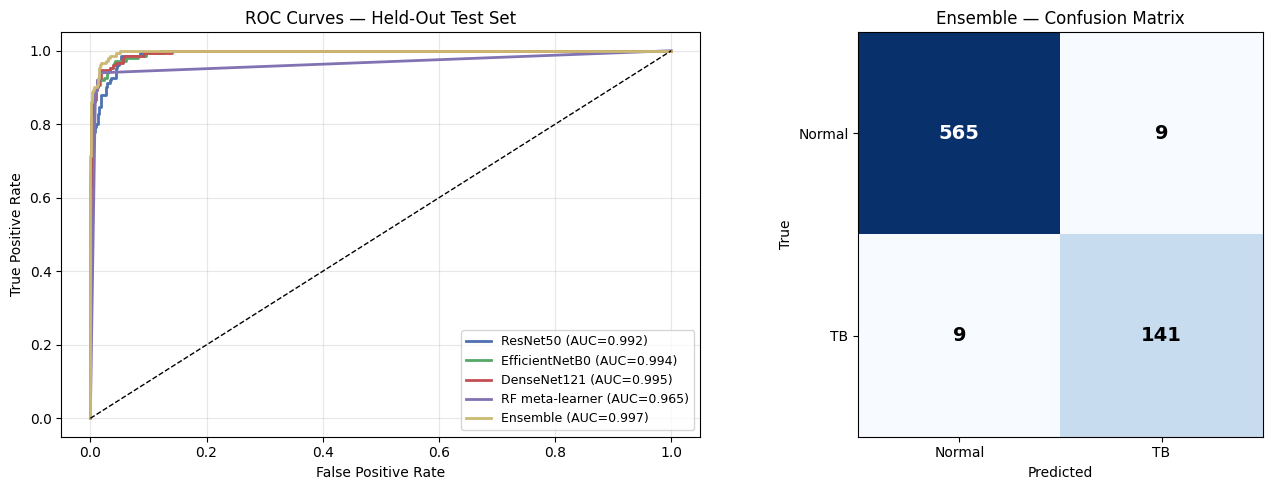

Saved → /kaggle/working/TB_results.png


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ROC curves
ax = axes[0]
colors = ["#4C72B0","#55A868","#C44E52","#8172B2","#CCB974"]
model_probs = {
    "ResNet50":        res_probs,
    "EfficientNetB0":  eff_probs,
    "DenseNet121":     den_probs,
    "RF meta-learner": rf_probs,
    "Ensemble":        ensemble_probs,
}
for (name, probs), col in zip(model_probs.items(), colors):
    fpr, tpr, _ = roc_curve(y_test, probs)
    auc = roc_auc_score(y_test, probs)
    ax.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})", color=col, lw=2)
ax.plot([0,1],[0,1],"k--", lw=1)
ax.set(xlabel="False Positive Rate", ylabel="True Positive Rate",
       title="ROC Curves — Held-Out Test Set")
ax.legend(loc="lower right", fontsize=9)
ax.grid(alpha=0.3)

# Ensemble confusion matrix
ax2 = axes[1]
cm   = confusion_matrix(y_test, (ensemble_probs>=0.5).astype(int))
im   = ax2.imshow(cm, cmap="Blues")
ax2.set_xticks([0,1]); ax2.set_xticklabels(["Normal","TB"])
ax2.set_yticks([0,1]); ax2.set_yticklabels(["Normal","TB"])
ax2.set(xlabel="Predicted", ylabel="True", title="Ensemble — Confusion Matrix")
for i in range(2):
    for j in range(2):
        ax2.text(j, i, str(cm[i,j]), ha="center", va="center",
                 color="white" if cm[i,j]>cm.max()/2 else "black",
                 fontsize=14, fontweight="bold")

plt.tight_layout()
plt.savefig("/kaggle/working/TB_results.png", dpi=300, bbox_inches="tight")
plt.show()
print("Saved → /kaggle/working/TB_results.png")


Per-CNN SHAP contribution (%):
model
dense     18.8
effnet    59.7
resnet    21.6


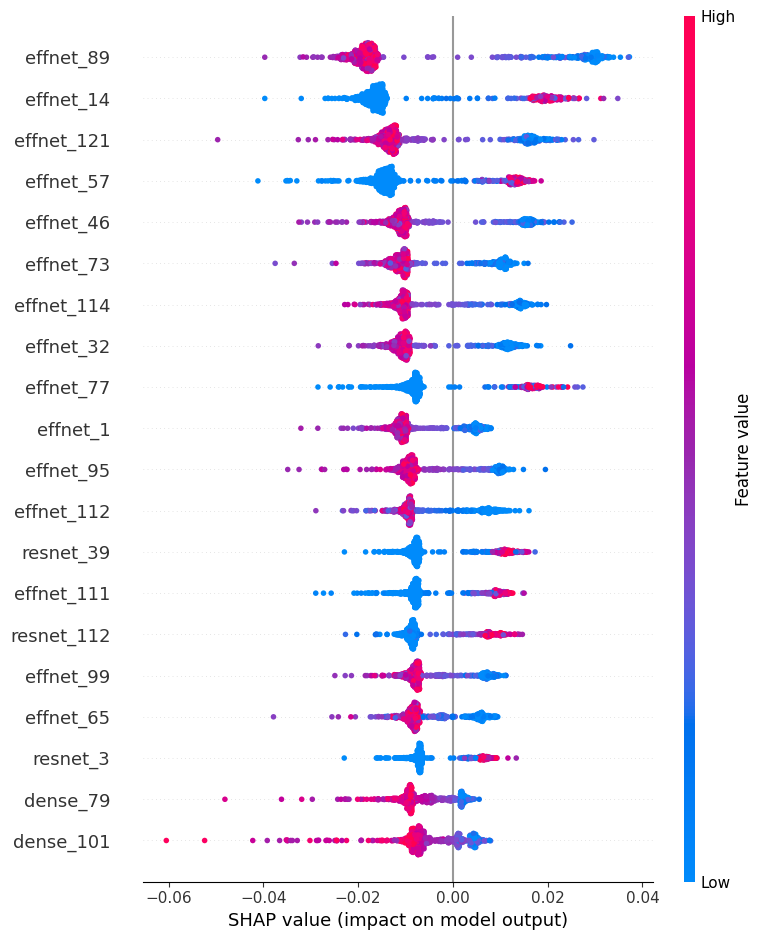

In [14]:
explainer   = shap.TreeExplainer(best_rf)
shap_values = explainer.shap_values(X_val_scaled)

n_res = feat_res_val.shape[1]
n_eff = feat_eff_val.shape[1]
n_den = feat_den_val.shape[1]
feat_names = ([f"resnet_{i}"  for i in range(n_res)] +
              [f"effnet_{i}"  for i in range(n_eff)] +
              [f"dense_{i}"   for i in range(n_den)])

sv = shap_values[:,:,1] if shap_values.ndim == 3 else shap_values

# Per-CNN contribution
imp_df = pd.DataFrame({"feature": feat_names,
                        "importance": np.abs(sv).mean(axis=0)})
imp_df["model"] = imp_df["feature"].str.split("_").str[0]
contrib = imp_df.groupby("model")["importance"].sum()
contrib_pct = (contrib / contrib.sum() * 100).round(1)
print("\nPer-CNN SHAP contribution (%):")
print(contrib_pct.to_string())
if contrib_pct.max() > 80:
    print(f"\n⚠ {contrib_pct.idxmax()} dominates ({contrib_pct.max()}%) — consider retraining weaker models")

shap.summary_plot(sv, X_val_scaled, feature_names=feat_names, max_display=20,
                  rng=np.random.default_rng(42))

In [18]:
import os
import joblib

os.makedirs('/kaggle/working/saved_models', exist_ok=True)

# ── Save Keras Models ──
resnet_model.save('/kaggle/working/saved_models/resnet50.keras')
eff_model.save('/kaggle/working/saved_models/efficientnetb0.keras')
dense_model.save('/kaggle/working/saved_models/densenet121.keras')

# ── Save Calibrated RF Meta-Learner ──
joblib.dump(calibrated_rf, '/kaggle/working/saved_models/calibrated_rf.pkl')

# ── Verify ──
print("Saved files:")
for f in os.listdir('/kaggle/working/saved_models'):
    size = os.path.getsize(f'/kaggle/working/saved_models/{f}') / (1024*1024)
    print(f"  {f}  →  {size:.1f} MB")

Saved files:
  efficientnetb0.keras  →  37.4 MB
  resnet50.keras  →  223.0 MB
  calibrated_rf.pkl  →  0.6 MB
  densenet121.keras  →  38.0 MB


In [20]:
resnet_model.save_weights('/kaggle/working/saved_models/resnet50.weights.h5')

# Check size
size = os.path.getsize('/kaggle/working/saved_models/resnet50.weights.h5') / (1024*1024)
print(f"resnet50.weights.h5 → {size:.1f} MB")

resnet50.weights.h5 → 222.8 MB
